# Streamlit

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from lightgbm import LGBMRegressor
from myfunctions import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
#base_dir = r'C:\FBr\Weiterbildung\Project\GitHub\sep24_cds_int_us-welding'
base_dir = r'D:\Entwicklungen\share\DataScienceProject\sep24_cds_int_us-welding'

ft_param_path = os.path.join(base_dir, 'ft_files', '03_feat_parameters.ft')
ft_modes_path = os.path.join(base_dir, 'ft_files', '03_coll_modes.ft')
ft_nodes_path = os.path.join(base_dir, 'ft_files', '03_coll_nodes.ft')
ft_defs_path = os.path.join(base_dir, 'ft_files', '03_coll_defs.ft')

df_params = pd.read_feather (ft_param_path)
df_modes = pd.read_feather (ft_modes_path)
df_nodes = pd.read_feather (ft_nodes_path)
df_defs = pd.read_feather (ft_defs_path)

dump_dir = os.path.join(base_dir, 'model_dumps')

In [3]:
# Select the relevant columns of df_params only
lst_param = df_params.columns.tolist()
lst_param_geom = lst_param[1:24]
lst_param_sel = [lst_param[0]] + lst_param_geom + lst_param[24:26] + lst_param[29:32] + lst_param[57:61] + lst_param[137:139]
df_params_1 = df_params[lst_param_sel]

In [4]:
# Load models

Exploration and visualization of the data

Data exploration

In [5]:
df_params_1.head(100)

,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,freq_long,mode_gain_long,mode_mac_long,slot_class,long_disp_mean,long_disp_max,long_disp_min,long_disp_nrdd,freq_delta_below,freq_delta_above
0,1001,175.06,121.95,240.31,4,75.993,43.235,2,78.219,59.508,...,19217.965,0.75609,0.921784,4-2,0.280277,0.398564,0.140101,4.477219,-122.562,61.289
1,1002,173.45,122.77,238.13,4,81.168,45.859,2,78.924,57.208,...,19386.656,0.75940,0.923429,4-2,0.293080,0.416231,0.135763,4.765604,-509.999,510.291
2,1003,175.85,116.71,238.10,4,77.532,45.260,2,80.099,49.215,...,20087.459,0.95450,0.971387,4-2,0.321250,0.430937,0.264546,2.526948,-830.970,126.812
3,1004,173.51,116.37,238.30,4,82.428,51.007,2,74.757,50.840,...,20209.177,0.90825,0.948260,4-2,0.318636,0.435829,0.181880,4.202228,-582.120,341.897
4,1005,175.60,118.72,241.04,4,76.576,45.981,2,78.773,64.702,...,19813.899,0.90749,0.979068,4-2,0.309465,0.376213,0.255784,2.092937,-169.319,645.366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,175.13,118.17,238.38,4,79.060,51.158,2,80.872,57.562,...,20233.910,0.77433,0.921493,4-2,0.302259,0.460016,0.124052,5.206389,-796.867,126.432
96,1097,174.32,119.14,240.99,4,74.494,46.789,2,77.106,65.917,...,19967.854,0.81098,0.960510,4-2,0.296686,0.395643,0.191501,3.467904,-216.560,561.015
97,1098,174.28,123.09,238.57,4,77.508,46.936,2,82.872,53.867,...,19239.180,0.87350,0.975183,4-2,0.303979,0.366455,0.236051,2.179953,-68.418,857.863
98,1099,174.76,115.05,240.04,4,79.014,51.881,2,76.445,57.222,...,20341.104,0.87015,0.905217,4-2,0.308363,0.440703,0.098320,5.818654,-754.451,398.535


In [6]:
df_modes.head(152)

,dp_no,mode_no,freq,rel_dev,mean_in_disp,mean_out_disp,mode_gain,mode_mac
0,1000,25,11705.549,120.61732,-0.121,0.002,0.01985,0.076401
1,1000,26,11987.927,412.69239,-0.009,0.002,0.26013,0.000220
2,1000,27,12187.892,474.99649,0.000,0.001,2.26471,0.000035
3,1000,28,12318.561,11.80434,-0.065,-0.046,0.71102,0.009971
4,1000,29,12598.709,847.60025,0.001,0.000,0.92230,0.000006
...,...,...,...,...,...,...,...,...
147,1001,96,23405.312,279.90924,-0.000,0.004,69.26305,0.000073
148,1001,97,23675.613,347.79353,-0.018,-0.003,0.17265,0.000213
149,1001,98,23754.253,203.12398,-0.046,-0.002,0.05382,0.010735
150,1001,99,23860.316,161.46847,-0.004,-0.007,1.96045,0.000435


In [7]:
df_nodes.head(495)

,dp_no,node_no,x_coord,y_coord,z_coord
0,1000,1,-120.01500,0.0,-76.720000
1,1000,11,-120.01500,0.0,76.720000
2,1000,12,-120.01500,0.0,57.540000
3,1000,13,-120.01500,0.0,38.360000
4,1000,14,-120.01500,0.0,19.180000
...,...,...,...,...,...
490,1000,10210,-37.47987,0.0,69.283814
491,1001,1,-120.15500,0.0,-82.064300
492,1001,12,-120.15500,0.0,82.064300
493,1001,13,-120.15500,0.0,63.827789


In [8]:
df_defs.head(495)

,dp_no,node_no,mode25,mode26,mode27,mode28,mode29,mode30,mode31,mode32,...,mode91,mode92,mode93,mode94,mode95,mode96,mode97,mode98,mode99,mode100
0,1000,1,0.134142,0.216114,0.193092,-0.297784,0.046671,0.101679,-0.038922,0.039048,...,-0.290045,-0.330238,-0.418750,-0.396922,0.167523,-0.294506,0.305611,0.242859,-0.131780,-0.102837
1,1000,11,0.133235,-0.224205,0.177632,-0.296075,-0.053283,-0.110080,-0.023488,0.037248,...,-0.295936,-0.325200,-0.413388,-0.399802,0.185901,0.240496,0.349572,0.235923,0.139851,-0.066484
2,1000,12,0.067980,-0.244073,0.067255,-0.170133,0.017068,-0.028849,-0.032300,-0.002932,...,0.002639,-0.088270,-0.416453,-0.475318,0.080366,0.157874,-0.031110,0.535567,-0.200790,-0.409373
3,1000,13,-0.013566,-0.263616,-0.039998,-0.027363,0.124321,0.080527,-0.013113,-0.022632,...,0.169028,0.109970,0.005401,-0.042836,-0.001065,0.016996,-0.298478,0.215014,-0.454417,-0.438804
4,1000,14,-0.091604,-0.232150,-0.146628,0.080373,0.196288,0.157715,-0.005128,-0.053346,...,0.000723,0.090866,0.728555,0.792384,-0.042708,-0.064504,-0.377651,-0.633504,-0.411714,-0.202440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,1000,10210,-0.052602,0.374043,-0.034945,-0.203935,0.034757,0.118696,0.099449,-0.026174,...,0.038006,0.188911,0.088049,0.076781,-0.079727,-0.015161,-0.123634,0.100086,-0.053007,-0.067978
491,1001,1,-0.065911,0.178204,0.259102,0.250183,0.010527,-0.210316,0.033066,0.096892,...,0.080021,0.337979,0.073709,-0.335636,-0.567224,-0.027954,0.000626,-0.270824,-0.221469,-0.122088
492,1001,12,0.066035,0.176695,0.364835,0.022659,0.016073,-0.197222,-0.029031,-0.090751,...,0.095241,-0.312241,-0.066837,0.317554,0.573101,0.024126,-0.036901,-0.242830,-0.242739,0.146983
493,1001,13,0.060209,0.157794,0.365830,-0.024725,0.045843,-0.082772,-0.035403,0.032874,...,0.106189,0.061989,-0.018170,0.349185,0.097354,0.380041,-0.043881,-0.243067,-0.416460,-0.066137


Example of DP 1001

In [9]:
dp = 1001

In [10]:
# Geometrical parameters
df_params.loc[df_params['dp_no'] == dp]

# Identified longitudinal mode for this design point
id_long = df_params.loc[df_params['dp_no'] == dp, 'mode_no_long'].item()
print ('Identified longitudinal mode:', id_long)

Identified longitudinal mode: 77


In [11]:
# List of modes around 77
lst_modes = range(id_long-3, id_long+4)
df_modes.loc[(df_modes['dp_no'] == dp) & (df_modes['mode_no'].isin(lst_modes))]

# Look at frequencies and MAC

,dp_no,mode_no,freq,rel_dev,mean_in_disp,mean_out_disp,mode_gain,mode_mac
125,1001,74,18846.436,10.88204,-0.205,-0.040,0.19463,0.017913
126,1001,75,18970.924,234.15326,0.006,-0.002,0.31228,0.000112
127,1001,76,19095.403,162.83428,-0.009,0.006,0.68261,0.000288
128,1001,77,19217.965,0.92217,-0.371,0.280,0.75609,0.921784
129,1001,78,19279.254,29.57338,0.357,-0.030,0.08529,0.210018
130,1001,79,19311.640,49.18443,0.021,-0.006,0.25861,0.001689
131,1001,80,20316.043,422.53310,-0.003,0.002,0.71839,0.000046


Data visualization

[]

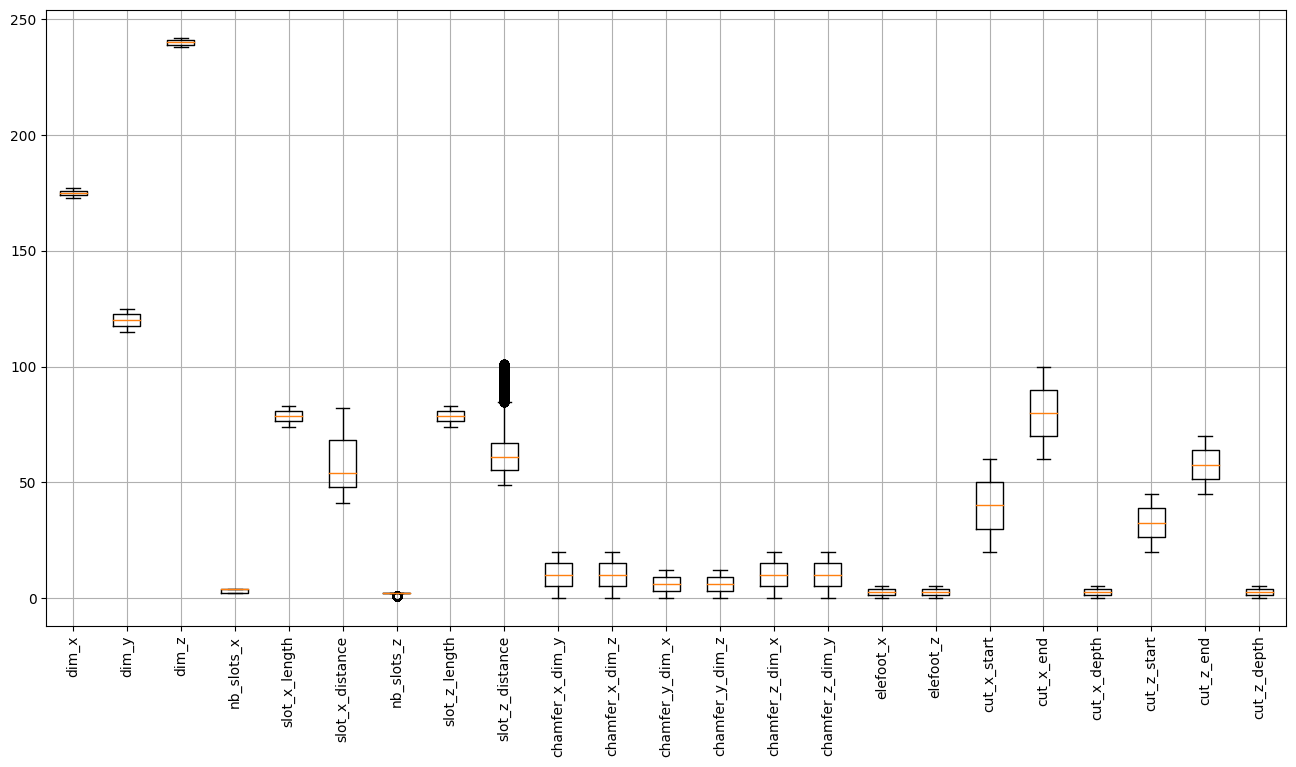

In [12]:
fig, ax = plt.subplots(figsize=(16, 8))
plt.boxplot(df_params[lst_param_geom], labels=lst_param_geom)
plt.xticks(rotation=90)
plt.grid(True)
plt.plot()

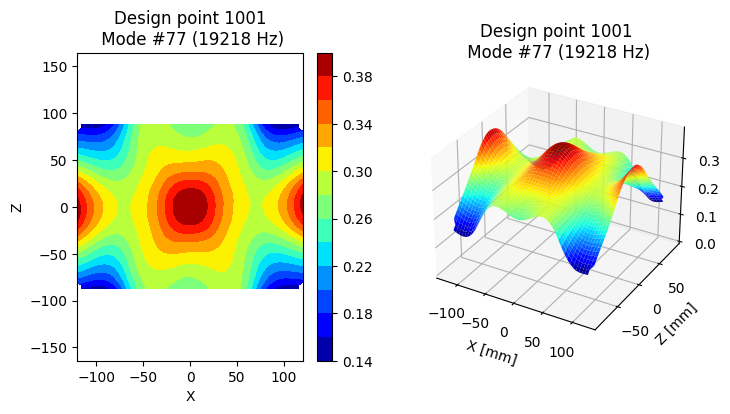

In [13]:
# Display displacements of the longitudinal mode
plot_displacement(df_modes, df_nodes, df_defs, dp, id_long, True);

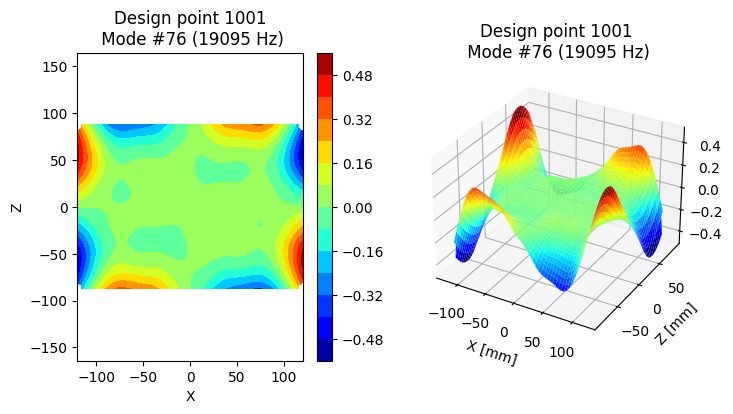

In [14]:
plot_displacement(df_modes, df_nodes, df_defs, dp, id_long-1, False);

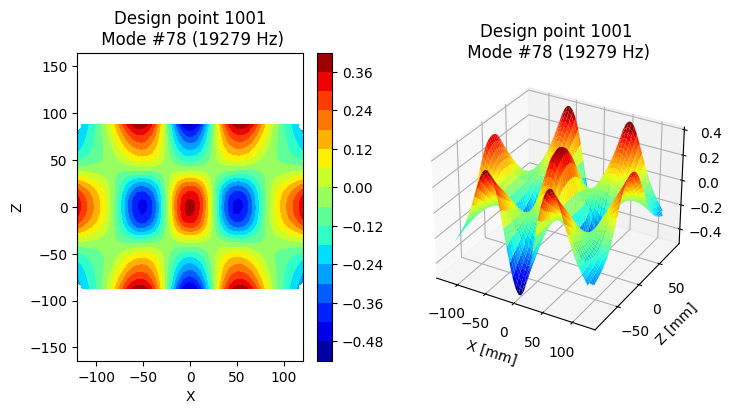

In [15]:
plot_displacement(df_modes, df_nodes, df_defs, dp, id_long+1, False);

Modelling of longitudinal frequencies

In [16]:
lst_param = df_params.columns.to_list()

# Explanatory variables: all slot classes are considered, we add the 4 encoded columns to the selected dataset
lst_slot_class = lst_param[541:545]
lst_expl = lst_param[1:4] + lst_param[5:7] + lst_param[8:24] + lst_param[32:34]
# Target variable is the frequency of the longitudinal mode
target = 'freq_long'

X = df_params[lst_expl + lst_slot_class]
y = df_params[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)

In [42]:
# MAC-Filtered data
df_params_filt = df_params.loc[df_params['mode_mac_long'] > 0.75]
X_filt = df_params_filt[lst_expl + lst_slot_class]
y_filt = df_params_filt[target]
X_train_filt, X_test_filt, y_train_filt, y_test_filt = train_test_split(X_filt, y_filt, test_size=0.2, random_state=55)

In [18]:
pipe_base_lgbm = pickle.load(open(os.path.join(dump_dir, '4_model_lgbm_base_long_frequencies.pkl'), 'rb'))
print ('Score of the test set:', pipe_base_lgbm.score(X_test, y_test))

Score of the test set: 0.9860463472284047


In [17]:
pipe_tuned_lgbm = pickle.load(open(os.path.join(dump_dir, '4_model_lgbm_tuned_long_frequencies.pkl'), 'rb'))
print ('Score of the test set:', pipe_tuned_lgbm.score(X_test, y_test))

Score of the test set: 0.9933359528253154


In [43]:
pipe_filt_lgbm = pickle.load(open(os.path.join(dump_dir, '6_model_lgbm_filt_long_frequencies.pkl'), 'rb'))
print ('Score of the test set:', pipe_filt_lgbm.score(X_test_filt, y_test_filt))

Score of the test set: 0.9970615545720903


In [44]:
y_pred_base_lgbm = pipe_base_lgbm.predict(X_test)
y_pred_tuned_lgbm = pipe_tuned_lgbm.predict(X_test)
y_pred_filt_lgbm = pipe_filt_lgbm.predict(X_test_filt)

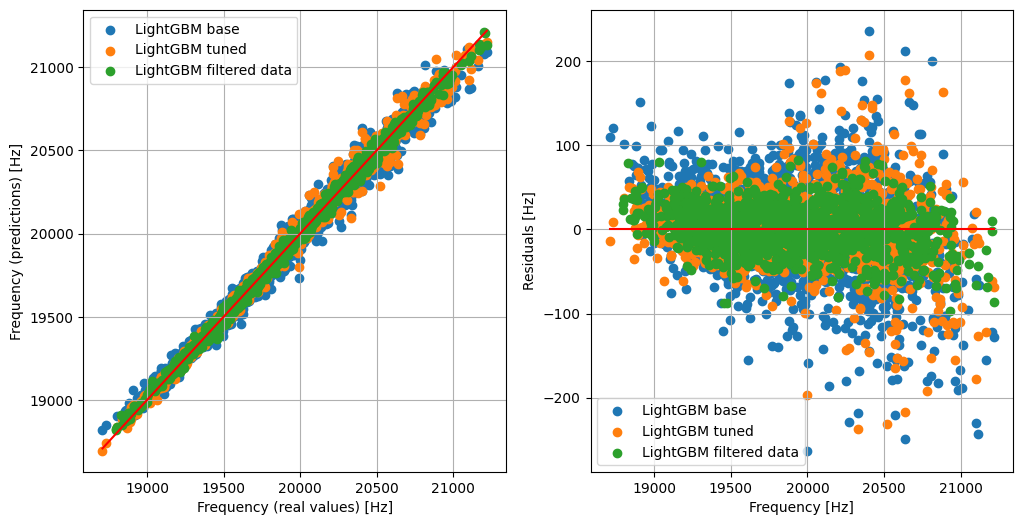

In [50]:
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(y_test, y_pred_base_lgbm, label='LightGBM base')
ax1.scatter(y_test, y_pred_tuned_lgbm, label='LightGBM tuned')
ax1.scatter(y_test_filt, y_pred_filt_lgbm, label='LightGBM filtered data')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='r')
ax1.set_xlabel('Frequency (real values) [Hz]')
ax1.set_ylabel('Frequency (predictions) [Hz]')
ax1.grid(True)
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(y_test, y_pred_base_lgbm-y_test, label='LightGBM base')
ax2.scatter(y_test, y_pred_tuned_lgbm-y_test, label='LightGBM tuned')
ax2.scatter(y_test_filt, y_pred_filt_lgbm-y_test_filt, label='LightGBM filtered data')
ax2.plot([y_test.min(), y_test.max()], [0, 0], color='r')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Residuals [Hz]')
ax2.grid(True)
ax2.legend()

plt.show()

In [51]:
print ('Mean Absolute Error (Base model):', mean_absolute_error(y_test, y_pred_base_lgbm), 'Hz')
print ('Mean Absolute Error (Tuned model):', mean_absolute_error(y_test, y_pred_tuned_lgbm), 'Hz')
print ('Mean Absolute Error (Filtered data):', mean_absolute_error(y_test_filt, y_pred_filt_lgbm), 'Hz')

Mean Absolute Error (Base model): 44.95743380320698 Hz
Mean Absolute Error (Tuned model): 28.179007775765847 Hz
Mean Absolute Error (Filtered data): 21.09528895723602 Hz
